In [1]:
from scdepth.bindings import Downsampler
from scdepth import fn, pl, fit
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#Load the pre-processed example sample
sample = 'Parse_WT_PBMC'
prefix = f'../parse/{sample}/scdepth'

full_summary = fn.parse_summary(prefix)

In [2]:
ds = Downsampler()

exclude_file = ''
max_hist = 50
build_matrices = False
calc_sau = False

ds.init(prefix, max_hist=max_hist, build_matrices=build_matrices, exclude_file=exclude_file,
        calc_sau=calc_sau)

if not os.path.isfile(prefix + '_fit_baseline.txt'):
    print('scdepth fit must be run on the sample for this to work')

nbl, bstats, full_stats = fit.baseline_fitter(prefix)
barcodes = fn.read_barcodes_meta(ds, prefix)
samples, bmap = fn.barcode2sample(ds)

In [3]:
cell_counts = {}
for s in samples:
    cnt =barcodes.loc[barcodes['sample'] == s, 'passed'].sum()
    cell_counts[s] = cnt
cell_counts['full'] = sum(cell_counts.values())

In [4]:
baselines = []
threads = 10
aggregate_only = True
ds.downsample([bstats.fraction], umi_len=full_summary.umi_length, 
            seed=42, threads=threads, aggregate_only=aggregate_only,
             barcode2sample=bmap, primer_mode='merge')
baselines.append((fn.get_rpm_hist(ds=ds)[0].copy(), ds.sample_total_mhists.copy(), fn.sample_stats(samples, ds, full_summary), fn.bulk_stats(ds, full_summary)))
ds.downsample([bstats.fraction], umi_len=full_summary.umi_length, 
            seed=42, threads=threads, aggregate_only=aggregate_only,
             barcode2sample=bmap, primer_mode='polyA')
baselines.append((fn.get_rpm_hist(ds=ds)[0].copy(), ds.sample_total_mhists.copy(), fn.sample_stats(samples, ds, full_summary), fn.bulk_stats(ds, full_summary)))
ds.downsample([bstats.fraction], umi_len=full_summary.umi_length, 
            seed=42, threads=threads, aggregate_only=aggregate_only,
             barcode2sample=bmap, primer_mode='random_hex')
baselines.append((fn.get_rpm_hist(ds=ds)[0].copy(), ds.sample_total_mhists.copy(), fn.sample_stats(samples, ds, full_summary), fn.bulk_stats(ds, full_summary)))

total samples = 4
total samples = 4
total samples = 4


In [5]:
steps = np.arange(10, full_stats.saturation + 1e-12, 5)
lfracs = fit.saturation_fracs(nbl, full_summary, steps) #, full=full_stats)
lfracs = lfracs[lfracs['fraction'] <= 1.0].reset_index(drop=True)

curves = []
ds.downsample(lfracs['fraction'].values, umi_len=full_summary.umi_length, 
            seed=42, threads=threads, aggregate_only=aggregate_only,
             barcode2sample=bmap, primer_mode='merge')
curves.append((fn.sample_stats(samples, ds, full_summary), fn.bulk_stats(ds, full_summary)))
ds.downsample(lfracs['fraction'].values, umi_len=full_summary.umi_length, 
            seed=42, threads=threads, aggregate_only=aggregate_only,
             barcode2sample=bmap, primer_mode='polyA')
curves.append((fn.sample_stats(samples, ds, full_summary), fn.bulk_stats(ds, full_summary)))
ds.downsample(lfracs['fraction'].values, umi_len=full_summary.umi_length, 
            seed=42, threads=threads, aggregate_only=aggregate_only,
             barcode2sample=bmap, primer_mode='random_hex')
curves.append((fn.sample_stats(samples, ds, full_summary), fn.bulk_stats(ds, full_summary)))

total samples = 4
total samples = 4
total samples = 4


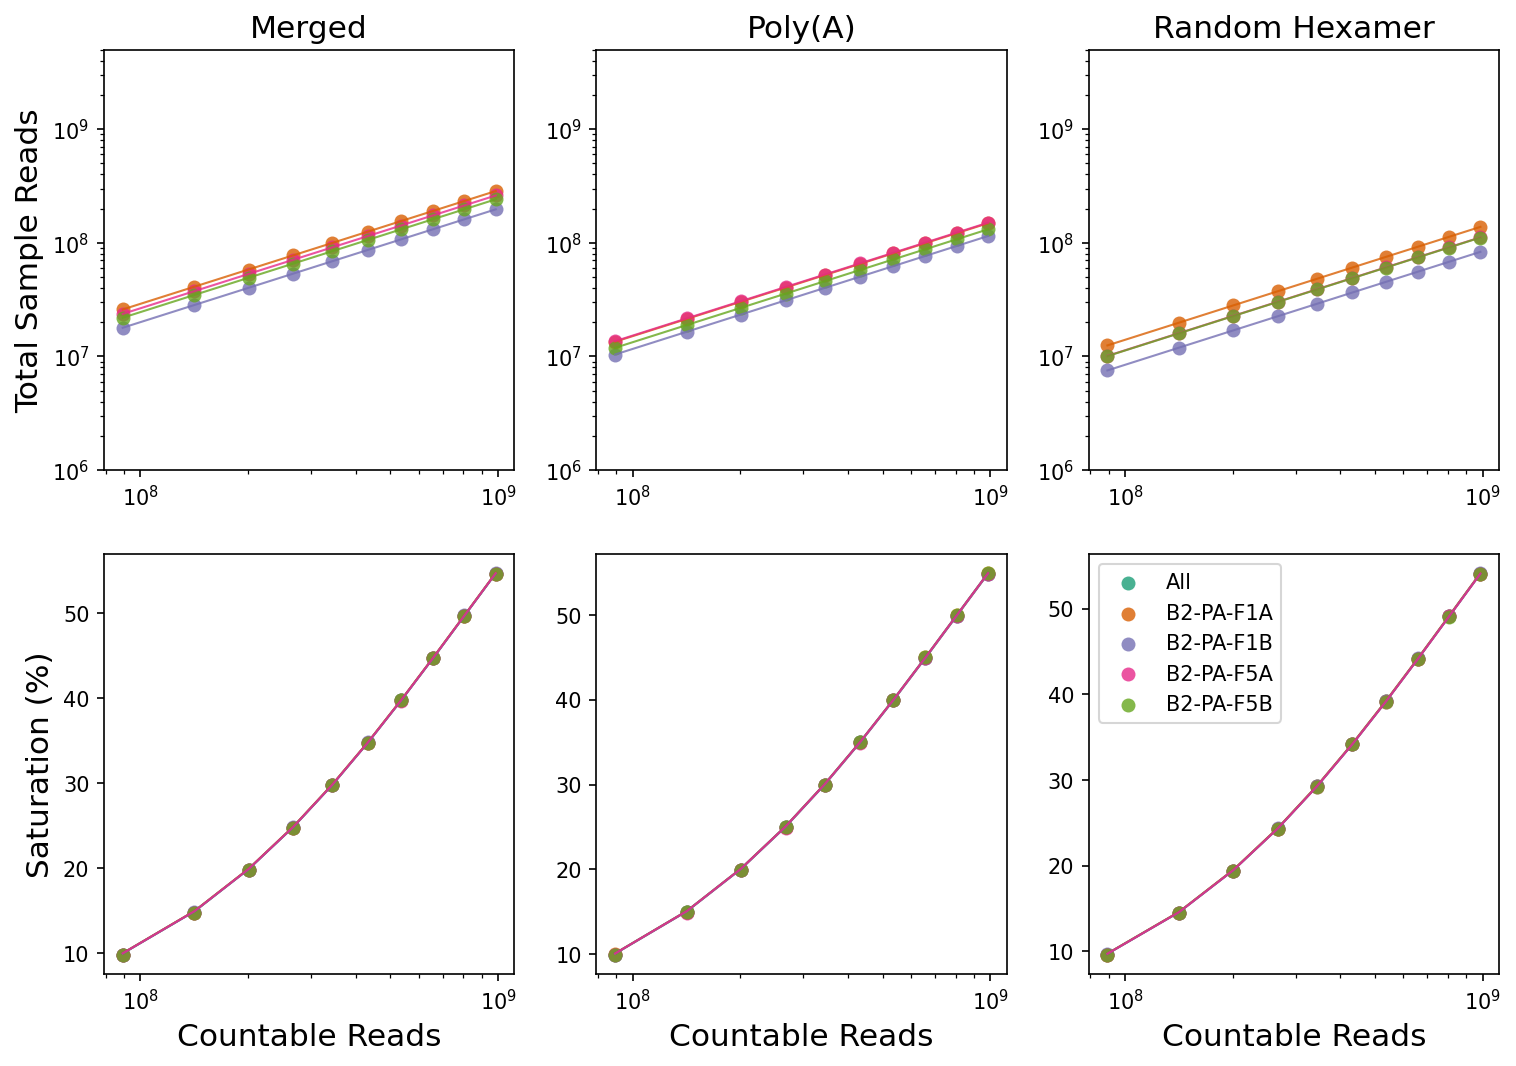

In [7]:
fit_summary = []
fig, axs = pl.figax(2,3, s=4)
full_count = curves[0][1]
for lab, (fh, h, ss, bs), (cs, cb), rx in zip(('Merged', 'Poly(A)', 'Random Hexamer'), baselines, curves, axs.T):
    #full merged dataset
    nbc = fit.NBLibFit()
    nbc.fit(fh, reads=bs.iloc[0].reads, molecules=bs.iloc[0].molecules)   
    psat = nbc.predict_saturation(cb['reads'])
    row = {'sample':'full', 'primer_mode':lab, 'cells':cell_counts['full'], 'total_reads':bs.iloc[0].reads, 
           'total_molecules':bs.iloc[0].molecules, 'saturation':bs.iloc[0].saturation, 
          'saturation_mae':np.mean(np.abs(psat - cb['saturation'].values).mean())}
    
    rx[1].scatter(full_count['reads'], cb['saturation'], s=45, color=plt.cm.Dark2.colors[0], label='All', alpha=0.8, lw=0)
    rx[1].plot(full_count['reads'], psat, lw=1, color=plt.cm.Dark2.colors[0], alpha=0.8)    
    for kk, v in nbc.serialize().items():
        row[kk] = v
    fit_summary.append(row)
    rx[0].set_title(lab, fontsize=15)
    for i, s in enumerate(samples):
        sel = ss[ss['sample'] ==s].iloc[0]
        csel = cs[cs['sample'] == s].sort_values('fraction')
        
        nbc = fit.NBLibFit()
        nbc.fit(h[i][0], reads=sel.total_reads, molecules=sel.total_molecules)
        psat = nbc.predict_saturation(csel['total_reads'])
        
        row = {'sample':s, 'primer_mode':lab, 'cells':cell_counts[s], 'total_reads':sel.total_reads, 'saturation':(100.0 - 100.0 * sel.total_molecules/sel.total_reads),
               'total_molecules':sel.total_molecules, 'saturation_mae':np.mean(np.abs(psat - cb['saturation'].values).mean())}
        rx[0].scatter(full_count['reads'], csel['total_reads'], s=45, color=plt.cm.Dark2.colors[i+1], label=s, alpha=0.8, lw=0)
        rx[0].plot(full_count['reads'], csel['total_reads'], lw=1, color=plt.cm.Dark2.colors[i+1], alpha=0.8)

        rx[1].scatter(full_count['reads'], csel['saturation'], s=45, color=plt.cm.Dark2.colors[i+1], label=s, alpha=0.8, lw=0)
        rx[1].plot(full_count['reads'], psat, lw=1, color=plt.cm.Dark2.colors[i], alpha=0.8)

        
        
        for kk, v in nbc.serialize().items():
            row[kk] = v

        fit_summary.append(row)
    
for ax in axs[0]:
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylim(10**6, 5*10**9)

for ax in axs[1]:
    ax.set_xscale('log')
    ax.set_xlabel('Countable Reads', fontsize=15)


axs[0,0].set_ylabel('Total Sample Reads', fontsize=15)    
axs[1,0].set_ylabel('Saturation (%)', fontsize=15)
axs[1,-1].legend(loc='upper left')
fit_summary = pd.DataFrame(fit_summary)
keep_cols = ['sample', 'primer_mode', 'cells', 'total_reads', 'total_molecules', 'saturation', 'ztnb_rhat',
       'ztnb_phat', 'ztnb_KS', 'nb_lib_L', 'saturation_mae']
fit_summary = fit_summary[keep_cols].copy()
fit_summary['nb_lib_L_per_cell'] = fit_summary['nb_lib_L'] / fit_summary['cells']
fit_summary.to_csv('../Figures/Table S2.csv', index=False)
fig.savefig('../Figures/Figure S10 AB Parse Types.svg', bbox_inches='tight')

In [ ]:
fig, axs = pl.figax(2, 2, w=6, h=4)
axs = axs.flatten()
fig.subplots_adjust(wspace=0.3)
idx = 0
xt = []
xl = []
for i, lab in enumerate(('Merged', 'Poly(A)', 'Random Hexamer')):
    st = idx
    for j, s in enumerate(['full'] + samples):
        sel = fit_summary[(fit_summary['primer_mode'] == lab) & (fit_summary['sample'] == s)]
        axs[3].bar(idx, sel['saturation_mae'], color=plt.cm.Dark2.colors[j], width=1, edgecolor='k')
        axs[0].bar(idx, sel['ztnb_KS'], color=plt.cm.Dark2.colors[j], width=1, edgecolor='k')
        axs[1].bar(idx, sel['ztnb_rhat'], color=plt.cm.Dark2.colors[j], width=1, edgecolor='k')

        axs[2].bar(idx, sel['nb_lib_L_per_cell']/1000, color=plt.cm.Dark2.colors[j], width=1, edgecolor='k')

        idx += 1
    xt.append(st + (idx - st)/2 - 0.5)
    xl.append(lab)
    idx += 1    
for ax in axs:
    ax.set_xticks(xt)
    ax.set_xticklabels(xl, fontsize=12)
axs[3].set_ylabel('Saturation MAE (pp)', fontsize=14)
axs[0].set_ylabel('ZT-NB KS', fontsize=14)
axs[1].set_ylabel('Amplification\nHeterogeneity ($\\hat{r}$)', fontsize=14)
axs[2].set_ylabel('$\\hat{L}$ / Cells (Thousands)', fontsize=14)
for ax in axs:
    ax.tick_params(axis='both', labelsize=12)
    ax.tick_params(axis='both', which='both', length=4)
fig.savefig('../Figures/Figure S10 CDEF Parse Types Parameters.svg', bbox_inches='tight')

In [ ]:
sd